# 06. Banka Kampanyası Yanıt Tahmini

**Kategori:** Sınıflandırma  
**Gerçek veri seti:** UCI Bank Marketing  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
**Amaç:** Bir müşterinin vadeli mevduat kampanyasına olumlu yanıt verip vermeyeceğini tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veri kalitesi ve EDA

In [2]:
df = pd.read_csv(DATA_DIR / "bank_marketing.csv")
display(df.head())
print("Boyut:", df.shape, "| Tekrar:", df.duplicated().sum())
display(pd.DataFrame({"tip": df.dtypes, "eksik": df.isna().sum(), "benzersiz": df.nunique()}))

Boyut: (45211, 17) | Tekrar: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


,tip,eksik,benzersiz
age,int64,0,77
job,object,0,12
marital,object,0,3
education,object,0,4
default,object,0,2
balance,int64,0,7168
housing,object,0,2
loan,object,0,2
contact,object,0,3
day,int64,0,31


,oran
y,
no,0.883
yes,0.117


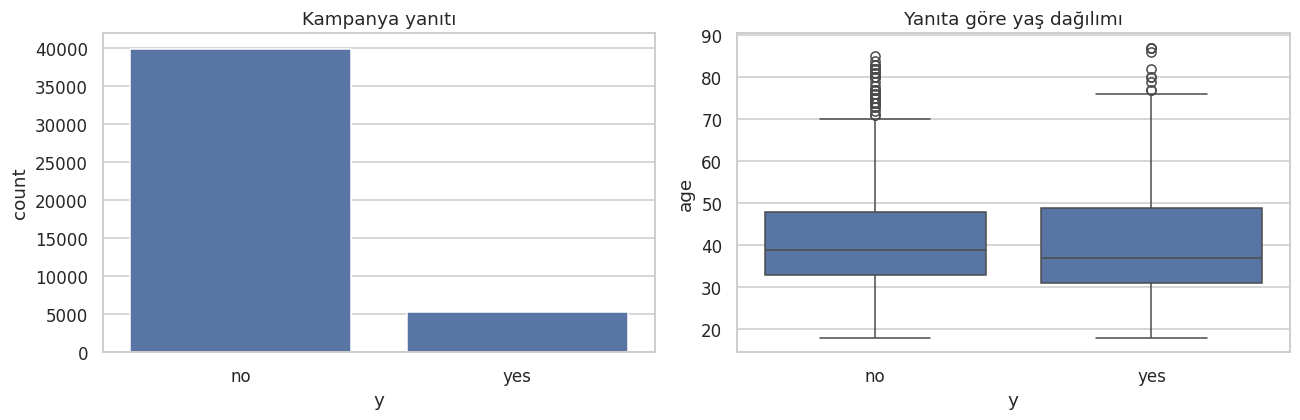

In [3]:
response_rate = df.y.value_counts(normalize=True).rename("oran")
display(response_rate.to_frame().round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="y", ax=axes[0])
axes[0].set(title="Kampanya yanıtı")
sns.boxplot(data=df.sample(6000, random_state=RANDOM_STATE), x="y", y="age", ax=axes[1])
axes[1].set(title="Yanıta göre yaş dağılımı")
plt.tight_layout(); plt.show()

## 2. Ön işleme ve dengesiz sınıflandırma

              precision    recall  f1-score   support

       hayır       0.97      0.86      0.91      7985
        evet       0.43      0.81      0.56      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



,F1,Balanced Accuracy
Linear SVM,0.558,0.832
Lojistik Regresyon,0.553,0.832


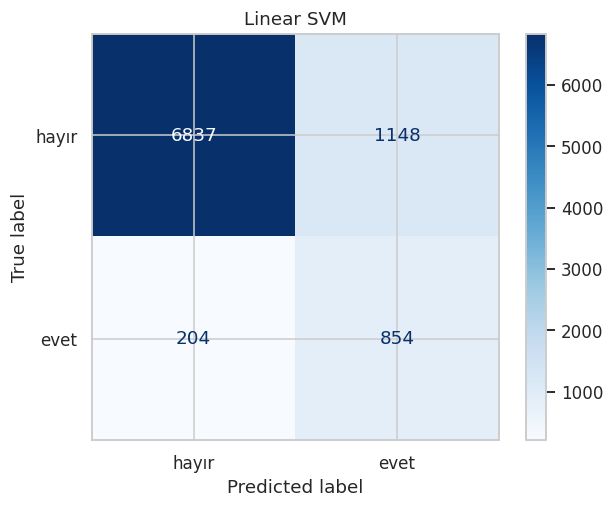

In [4]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

X, y = df.drop(columns="y"), df.y.map({"no": 0, "yes": 1})
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns
preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore", min_frequency=20)), cat_cols),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE
)
candidates = {
    "Lojistik Regresyon": LogisticRegression(max_iter=2500, class_weight="balanced"),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}
fitted = {name: make_pipeline(clone(preprocess), model).fit(X_train, y_train)
          for name, model in candidates.items()}
rows = {name: {"F1": f1_score(y_test, model.predict(X_test)),
               "Balanced Accuracy": balanced_accuracy_score(y_test, model.predict(X_test))}
        for name, model in fitted.items()}
scores = pd.DataFrame(rows).T.sort_values("F1", ascending=False)
display(scores.round(3))
best_name = scores.index[0]; best_model = fitted[best_name]; pred = best_model.predict(X_test)
print(classification_report(y_test, pred, target_names=["hayır", "evet"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["hayır", "evet"], cmap="Blues")
plt.title(best_name); plt.show()

In [5]:
joblib.dump({"best_name": best_name, "best_model": best_model, "all_models": fitted,
             "features": X.columns.tolist(), "metrics": scores.to_dict()},
            MODEL_DIR / "06_banka_pazarlama.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "06_banka_pazarlama.json", "w"), indent=2)

## Sonuç

Olumlu yanıt azınlıkta olduğu için yalnızca accuracy kullanmak yanıltıcı olurdu. Model seçimi F1 ile,
ikincil kontrol balanced accuracy ile yapıldı. Kampanya süresi (`duration`) görüşme bittikten sonra
bilindiğinden, arama öncesi hedefleme senaryosunda bu sütun çıkarılmalıdır.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **müşteri yanıtını sınıflandırma** biçimindedir.
Bu notebookta **45.211 gerçek kayıt, sınıf dengesizliği, F1/balanced accuracy ve zamanlama kaynaklı sızıntı notu** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).